### Module importation

In [1]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt



from scipy.stats import boxcox
from scipy.stats.mstats import normaltest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error



from sklearn.pipeline import Pipeline


### Data Loading and Inspection

In [9]:
df = pd.read_csv('C:/Users/Tammy/Desktop/Machine-Learning-Projects/Supervised ML (Regression)/Car Price Prediction/data/CarPrice.csv')

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [11]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### We have 25 features, with one up for prediction. Hence we have 24 features to select features for predicting car prices.
We will inspect only the numeric features and hence drop all non_numeric features

In [13]:
# Selecting only numeric features 

df = df.select_dtypes(include=['number'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   wheelbase         205 non-null    float64
 3   carlength         205 non-null    float64
 4   carwidth          205 non-null    float64
 5   carheight         205 non-null    float64
 6   curbweight        205 non-null    int64  
 7   enginesize        205 non-null    int64  
 8   boreratio         205 non-null    float64
 9   stroke            205 non-null    float64
 10  compressionratio  205 non-null    float64
 11  horsepower        205 non-null    int64  
 12  peakrpm           205 non-null    int64  
 13  citympg           205 non-null    int64  
 14  highwaympg        205 non-null    int64  
 15  price             205 non-null    float64
dtypes: float64(8), int64(8)
memory usage: 25.8 K

### Dropping Car_ID and Symboling since they are just for identification 

In [14]:
df = df.drop(['car_ID', 'symboling'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wheelbase         205 non-null    float64
 1   carlength         205 non-null    float64
 2   carwidth          205 non-null    float64
 3   carheight         205 non-null    float64
 4   curbweight        205 non-null    int64  
 5   enginesize        205 non-null    int64  
 6   boreratio         205 non-null    float64
 7   stroke            205 non-null    float64
 8   compressionratio  205 non-null    float64
 9   horsepower        205 non-null    int64  
 10  peakrpm           205 non-null    int64  
 11  citympg           205 non-null    int64  
 12  highwaympg        205 non-null    int64  
 13  price             205 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 22.6 KB


### EXPLORATORY DATA ANALYSIS TO CHECK FOR RELATIONSHIP

c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


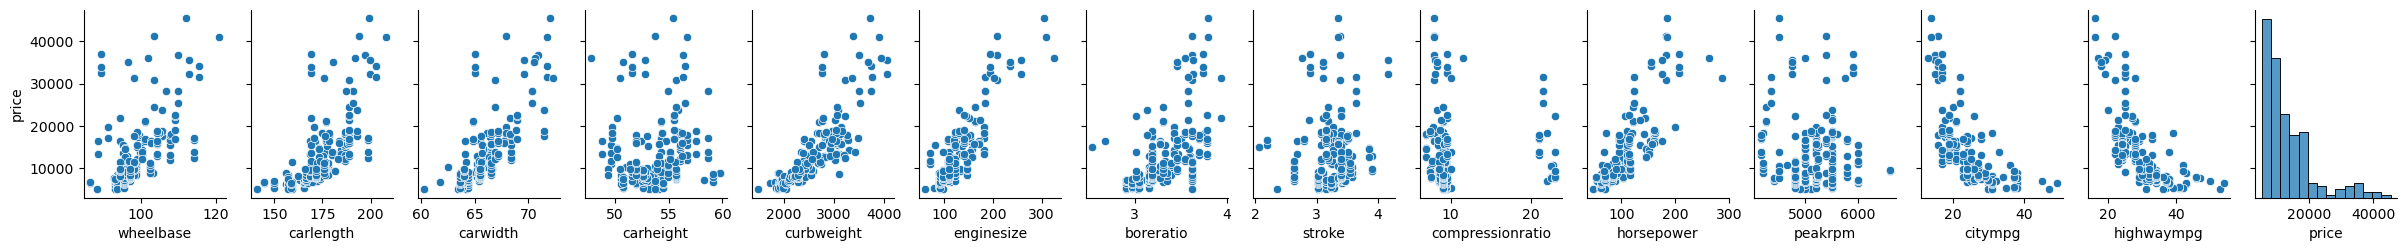

In [15]:
sns.pairplot(data=df, x_vars=df, y_vars='price', height=2.5, aspect=0.7)

In [22]:
price_correlations = df.corr()['price'].sort_values(ascending=False)
print(price_correlations)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


<Axes: >

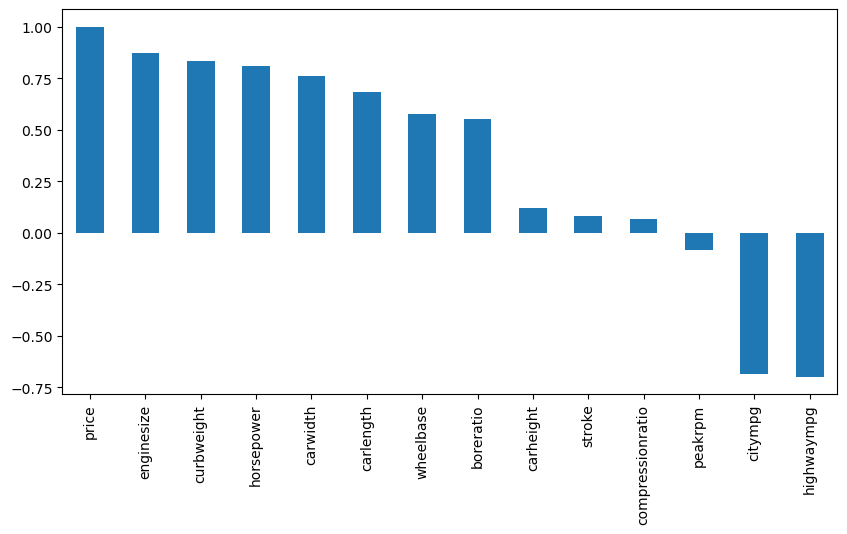

In [23]:
price_correlations.plot(kind='bar', figsize=(10, 5))

### From the results above, I will pick features that highly negative and positively correlated with price.
I will only select  values greate than -0.65 and 0.65

### This will lead to a multiple linear relationship (MLR)

In [24]:
price_correlations = pd.DataFrame(price_correlations)
print(price_correlations)

                     price
price             1.000000
enginesize        0.874145
curbweight        0.835305
horsepower        0.808139
carwidth          0.759325
carlength         0.682920
wheelbase         0.577816
boreratio         0.553173
carheight         0.119336
stroke            0.079443
compressionratio  0.067984
peakrpm          -0.085267
citympg          -0.685751
highwaympg       -0.697599


### EDA for Prediction Variable

C:\Users\Tammy\AppData\Local\Temp\ipykernel_12356\1391417071.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'], kde=True, hist=True)
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[]

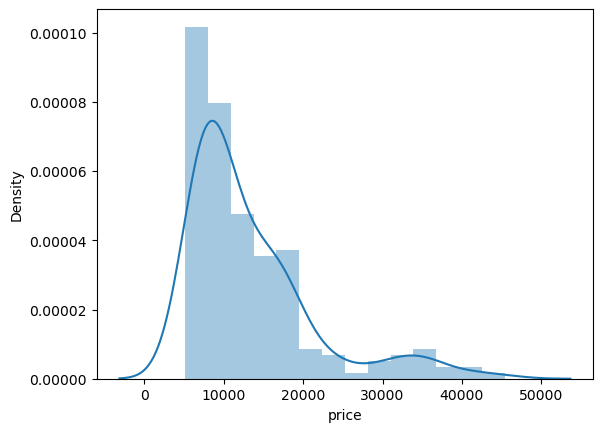

In [41]:
sns.distplot(df['price'], kde=True, hist=True)
plt.plot()

### Our Prediction Feature is not normally distributed, hence we will apply log to the price for Transformation

C:\Users\Tammy\AppData\Local\Temp\ipykernel_12356\107377777.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_log'], kde=True, hist=True)
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log', ylabel='Density'>

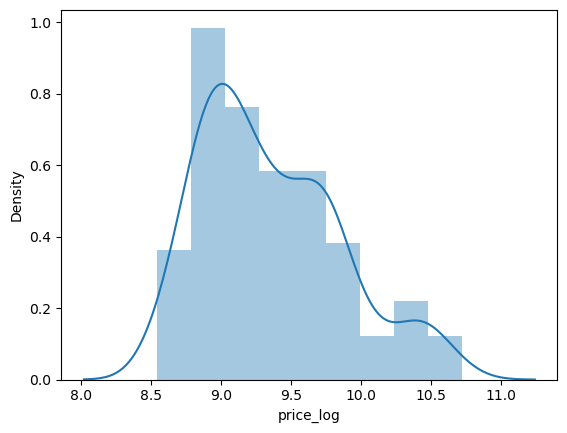

In [28]:
df['price_log'] = np.log1p(df['price'])
sns.distplot(df['price_log'], kde=True, hist=True)

### Checking for Correlation between log['Price'] and Independent Variables

In [29]:
correlation_matrix = df.corr()
correlation_with_log = correlation_matrix['price_log'].sort_values(ascending=False)
print(correlation_with_log)

price_log           1.000000
price               0.957661
curbweight          0.891235
enginesize          0.831990
horsepower          0.825836
carwidth            0.802544
carlength           0.767859
wheelbase           0.629399
boreratio           0.610563
carheight           0.162795
stroke              0.097990
compressionratio    0.085143
peakrpm            -0.088454
citympg            -0.771611
highwaympg         -0.775193
Name: price_log, dtype: float64


### based on this, we will select features with correlation less than -0.75 and greater than 0.75

In [36]:
X = pd.DataFrame(correlation_with_log[correlation_with_log > 0.75]).drop('price_log', axis=0)
Y = df['price_log']
features = X.index.tolist()
print(features)


['price', 'curbweight', 'enginesize', 'horsepower', 'carwidth', 'carlength']


### Splitting Data into training and Test

In [37]:
from sklearn.model_selection import train_test_split
SEED = 42

X_train, X_test, Y_train, Y_test = train_test_split(df[features], Y, test_size=0.3, random_state = SEED)

### Data Preprocessing with Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Defining the MLR model
lr = LinearRegression()

lr.fit(X_train_scaled, Y_train)
y_hat = lr.predict(X_test_scaled)
print(y_hat)

[10.38152385  9.80604689  9.11545554  9.40287422 10.28753701  8.95460035
  8.93014315  9.05008959  9.21626996  8.98050958  9.3810822   9.03152935
  9.63235404  9.1397248  10.77210254  8.84478087  8.67528716  9.35521629
  9.03079165  9.16905558  9.05672097  9.4368069   8.95381522  8.67634871
  8.8580594  10.98480079  9.13375409  9.51009694  8.99592394  9.45827771
 10.09405124  8.82886933  9.04836125  9.83605719  8.99077883 10.20634973
  9.31172143  9.35428973  8.95601134  9.4734972   9.01004861  9.55893807
  9.63395115  8.99462043  8.9244037   9.06275605  8.82886933  8.86062084
  9.63057155  9.36799533  8.81043983  9.61937136  8.86210438  9.06566994
  8.95887883  9.44080162  9.0720485   9.40162331 10.62568898  8.75797884
  9.11463661  9.5536971 ]


In [50]:
coef_df = pd.DataFrame({"Feature": features, "Coefficient": lr.coef_})
print(coef_df.sort_values(by="Coefficient", ascending=False))
print('Intercept:', lr.intercept_)

      Feature  Coefficient
0       price     0.410594
1  curbweight     0.114508
3  horsepower     0.087384
5   carlength     0.077476
4    carwidth    -0.032432
2  enginesize    -0.144183
Intercept: 9.368621604942058


### Model Evaluation

In [44]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

R_Squared = r2_score(Y_test, y_hat)
mse = mean_squared_error(Y_test, y_hat)
mae = mean_absolute_error(Y_test, y_hat)

print(f'R-Squared: {R_Squared}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

R-Squared: 0.9618369999648039
MSE: 0.009835910064896255
MAE: 0.07323624465995547


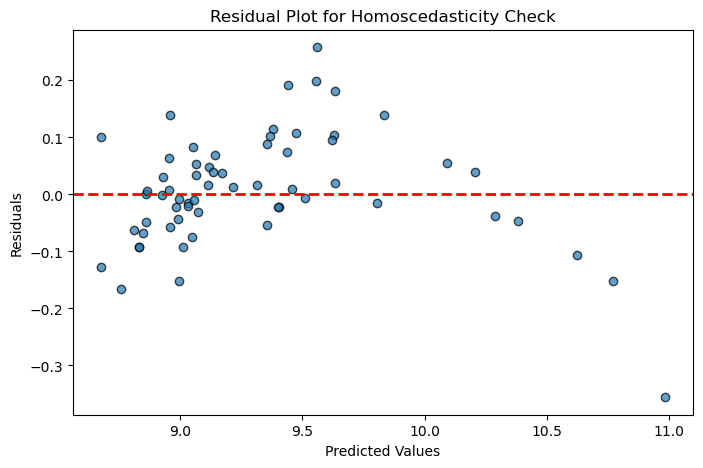

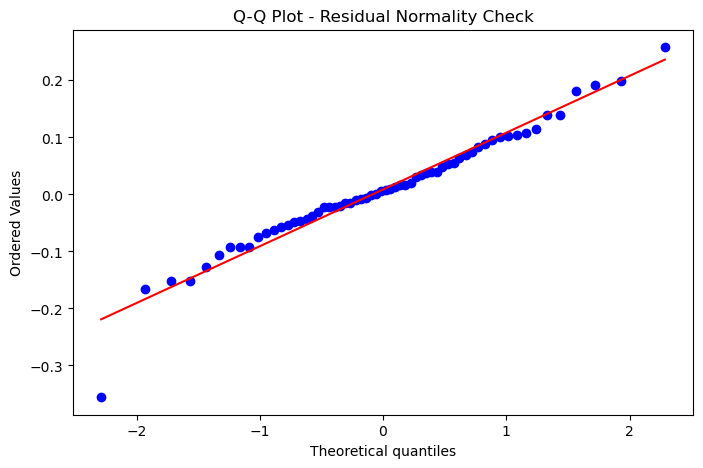

In [ ]:
from scipy import stats
residuals = Y_test - y_hat

# RESIDUAL PLOT & HOMOSCEDASTICITY 
plt.figure(figsize=(8, 5))
plt.scatter(y_hat, residuals, alpha=0.7, edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Homoscedasticity Check')
plt.show()

# Q-Q PLOT (Normality of Residuals) 
plt.figure(figsize=(8, 5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot - Residual Normality Check')
plt.show()

In [59]:
df['predicted_price'] = lr.intercept_ + np.dot(scaler.transform(df[features]), lr.coef_)
df['predicted_price'] = np.expm1(df['predicted_price'])
df['residuals'] = df['price'] - df['predicted_price']
df[['price', 'predicted_price', 'residuals']].head(10)

,price,predicted_price,residuals
0,13495.000,11615.674598,1879.325402
1,16500.000,13604.622010,2895.377990
2,16500.000,14610.051185,1889.948815
3,13950.000,12197.035957,1752.964043
4,17450.000,15232.155477,2217.844523
5,15250.000,12590.806680,2659.193320
6,17710.000,15751.308432,1958.691568
7,18920.000,17197.499474,1722.500526
8,23875.000,24955.245165,-1080.245165
9,17859.167,18142.123364,-282.956364


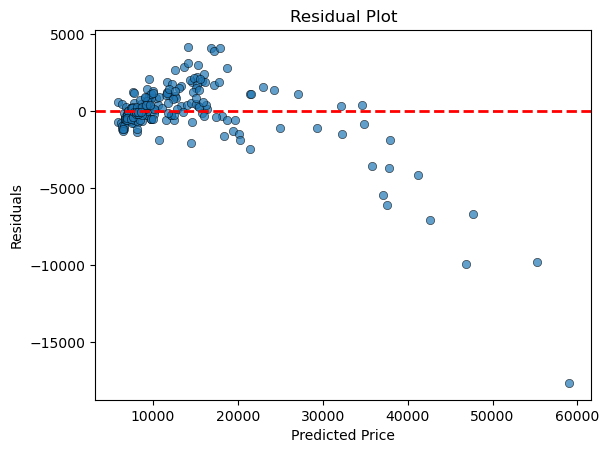

In [63]:
sns.scatterplot(
    x=df['predicted_price'], y=df['residuals'], alpha=0.7, edgecolor='k'
)

plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

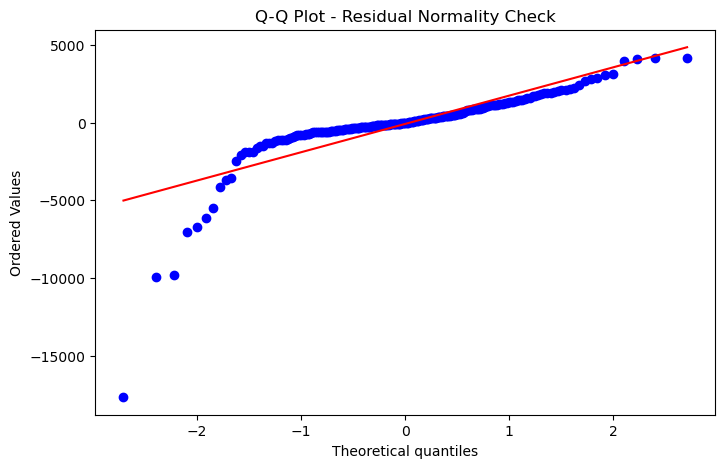

In [64]:
plt.figure(figsize=(8, 5))
stats.probplot(df['residuals'], dist='norm', plot=plt)
plt.title('Q-Q Plot - Residual Normality Check')
plt.show()

### Building a Pipeline

In [65]:
steps=[('scaler', StandardScaler()), ('lm',  LinearRegression())]

pipe = Pipeline(steps=steps)
pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['price','curbweight','enginesize','horsepower','carwidth','carlength']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
car_price_predictions = pipe.predict(X_test)
mse = mean_squared_error(Y_test, car_price_predictions)
mae = mean_absolute_error(Y_test, car_price_predictions)
rmse = np.sqrt(mse)
rmse
r2_score(car_price_predictions, Y_test)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'R²: {r2_score(car_price_predictions, Y_test)}')

MSE: 0.009835910064896255
MAE: 0.07323624465995547
RMSE: 0.09917615673586194
R²: 0.9619653948697234
